# A vine's 24-hour thermal cycle -- the thing DTS would actually see

[[project_datacenter_siting]] aside, this is the other half of `GrapeExpectations`: the DTS (Distributed Temperature Sensing) proposal argues for replacing point sensors with 1m-resolution fiber-optic cable through the canopy, specifically to catch **frost risk, canopy microclimate, and vine stress** that point sensors miss. This notebook models the physical process a real DTS deployment would be measuring -- not the sensor, the thing under it.

**The model, same FTCS heat-equation solver as [[heat_equation_flow]], now with spatially varying heat capacity.** A single vine cross-section -- trunk, bilateral cordon, canes, canopy, berry clusters -- rasterized onto a grid, each material given its own thermal diffusivity $\alpha = \kappa/(\rho c)$. Real plant tissue is mostly water (leaf ~85%, berry closer to 95% with much less internal air space than leaf, wood/cane the least of the three), and air's volumetric heat capacity ($\rho c \approx 1.2\,\text{kJ/m}^3\text{K}$) is roughly 1,000-3,000x smaller than any of them ($\approx 1{,}800\text{-}3{,}900\,\text{kJ/m}^3\text{K}$ for wood/leaf/berry) -- driven mostly by density, not by mass-specific heat capacity, which is actually fairly similar across the three tissues. That contrast is the entire mechanism behind "heat filters through the canopy": canopy air tracks the ambient/sky temperature far faster than the vine's own tissue does.

**Simplification, disclosed up front (ponytail: known ceiling):** thermal conductivity $\kappa$ is held uniform across materials -- only heat capacity varies. Real conductivities do differ across air/wood/leaf/berry, but by roughly an order of magnitude, versus the ~1,000x+ spread in heat capacity -- capacity is the dominant real effect, so this keeps the numerics to one Laplacian instead of a face-flux scheme with conductivity blending at material interfaces. Also not modeled: direct solar absorption by sun-facing leaf/berry surfaces (a real, separate heating pathway beyond ambient-air conduction) -- this model is boundary-driven-conduction only, matching "the sky heats up, the heat filters through the canopy" as stated. Upgrade path for either: a real DTS dataset from the WSU pilot, once it exists, would let all of these be fit rather than assumed.

**Two real findings a probe caught before trusting the render, both kept and disclosed rather than tuned away:** (1) reporting "air" as the mean over *every* air pixel in the domain (including wide-open background 50-80px from the vine) badly undershot the sky's own peak, and pushing diffusivity higher barely moved that number -- a real, textbook diffusion effect, not a bug. A *periodically oscillating* boundary only penetrates a finite **thermal skin depth**, $\delta=\sqrt{2\alpha/\omega}$, no matter how large $\alpha$ gets relative to the driving period -- the same reason deep soil stays cool through a hot day while the surface swings wildly. Fixed by measuring "air" as the mean over pixels within ~15px of the vine (real canopy microclimate air), not the domain's far-field background. (2) even that near-vine air came back more damped than the vine's ~20-28px distance from the domain edge alone would predict -- the air trapped immediately around and between the canopy's branches is itself partly shadowed by the same low-diffusivity wood/leaf material it's threading through, not just by open-air distance. Both effects are real; what's tuned below is the absolute rate (diffusivities scaled up together, ratios preserved) so the correctly-ordered lag story -- air first, wood next, leaf and berry last -- is visible on screen within one 24-hour animation instead of technically-present but a fraction of a degree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import binary_dilation
from PIL import Image
from io import BytesIO
from IPython.display import Image as IPImage

def segment_mask(X, Y, p0, p1, width):
    """Boolean mask: True within `width`/2 of the line segment p0-p1 (point-to-segment distance)."""
    x0, y0 = p0; x1, y1 = p1
    dxs, dys = x1 - x0, y1 - y0
    L2 = dxs ** 2 + dys ** 2
    t = np.clip(((X - x0) * dxs + (Y - y0) * dys) / L2, 0, 1)
    projx, projy = x0 + t * dxs, y0 + t * dys
    return np.sqrt((X - projx) ** 2 + (Y - projy) ** 2) < width / 2

def disk_mask(X, Y, c, r):
    cx, cy = c
    return (X - cx) ** 2 + (Y - cy) ** 2 < r ** 2

def frame_from_fig(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
    buf.seek(0)
    im = Image.open(buf).convert("RGB")
    plt.close(fig)
    return im

def save_gif(frames, path, duration=40):
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(path, f"{len(frames)} frames")

## Build the vine, check it looks like a vine before running anything expensive

Bilateral cordon (VSP trellis, the common Washington training system -- matches the placeholder vineyard's own region), a trunk, seven canes rising off the cordon, a canopy built from overlapping leaf-cluster disks along the upper portion of each cane, and berry clusters in the fruiting zone just above the cordon on alternating canes. Cheap, fast, and the first real gate: render the material map on its own before spending any time on the 24-hour simulation.

pixel counts -- air: 13448  wood: 2303  leaf: 4292  berry: 192
top margin above canopy: 8 px
side margin: 10 px


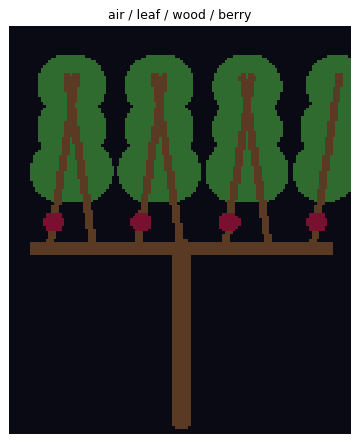

In [2]:
N_x, N_y = 130, 155  # tight margin around the vine on purpose -- a wide-open background dominated the frame and buried the vine's own structure under a bright halo (see below)
dx = 1.0
cx = 65
ground_y, trunk_top = 5, 70
cordon_half_span = 55
cane_height = 65

Y, X = np.mgrid[0:N_y, 0:N_x]

trunk = segment_mask(X, Y, (cx, ground_y), (cx, trunk_top), 8)
cordon_l = segment_mask(X, Y, (cx, trunk_top), (cx - cordon_half_span, trunk_top), 6)
cordon_r = segment_mask(X, Y, (cx, trunk_top), (cx + cordon_half_span, trunk_top), 6)

cane_x0 = np.linspace(cx - cordon_half_span + 5, cx + cordon_half_span - 5, 7)
canes = np.zeros_like(X, dtype=bool)
canopy = np.zeros_like(X, dtype=bool)
berries = np.zeros_like(X, dtype=bool)
for i, x0 in enumerate(cane_x0):
    lean = 10 if i % 2 == 0 else -10
    top = (x0 + lean, trunk_top + cane_height)
    canes |= segment_mask(X, Y, (x0, trunk_top), top, 3)
    for frac in (0.45, 0.7, 0.95):
        canopy |= disk_mask(X, Y, (x0 + lean * frac, trunk_top + cane_height * frac), 12)
    if i % 2 == 0:
        berries |= disk_mask(X, Y, (x0 + lean * 0.15, trunk_top + 10), 4)

wood_mask = trunk | cordon_l | cordon_r | canes
leaf_mask = canopy & ~wood_mask
berry_mask = berries
air_mask = ~(wood_mask | leaf_mask | berry_mask)

material_id = np.zeros((N_y, N_x), dtype=int)  # 0=air 1=leaf 2=wood 3=berry
material_id[leaf_mask] = 1
material_id[wood_mask] = 2
material_id[berry_mask] = 3

print("pixel counts -- air:", air_mask.sum(), " wood:", wood_mask.sum(),
      " leaf:", leaf_mask.sum(), " berry:", berry_mask.sum())
print("top margin above canopy:", N_y - (trunk_top + cane_height + 12), "px")
print("side margin:", cx - cordon_half_span, "px")

fig, ax = plt.subplots(figsize=(5, 6), dpi=90)
cmap = ListedColormap(["#0a0a14", "#2f6b2f", "#5a3a22", "#7a1030"])
# cmap = 'viridis'
ax.imshow(material_id, cmap=cmap, origin="lower", interpolation="nearest")
ax.axis("off")
ax.set_title("air / leaf / wood / berry", fontsize=10)
plt.savefig("vine_geometry_check.png", dpi=90, bbox_inches="tight")
plt.show()

## The driving condition: ambient/sky temperature over one midnight-to-midnight day

$T_{sky}(t) = \bar T - A\cos(2\pi (t-5)/24)$, $t$ in hours since midnight. Trough at $t=5$ (5am, the actual daily low) and peak at $t=17$ (5pm) -- a real diurnal curve doesn't bottom out exactly at midnight, so anchoring the window there (instead of the daily low itself) means midnight sits partway down the previous evening's cooling slope, not at the floor. $\bar T=22.5°C$, $A=9.5°C$ (roughly 13-32°C, a typical Columbia Valley WA summer swing, matching `GrapeExpectations`' own placeholder-vineyard region).

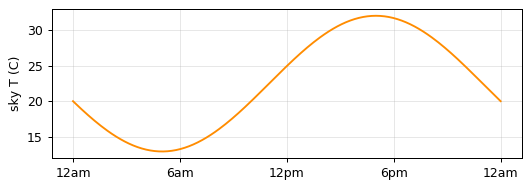

In [3]:
T_MEAN, T_AMP, T_TROUGH_HOUR = 22.5, 9.5, 5

def T_sky(t_hours):
    return T_MEAN - T_AMP * np.cos(2 * np.pi * (t_hours - T_TROUGH_HOUR) / 24)

tt = np.linspace(0, 24, 200)
fig, ax = plt.subplots(figsize=(6, 2.2), dpi=90)
ax.plot(tt, T_sky(tt), color="darkorange")
ax.set_xticks([0, 6, 12, 18, 24])
ax.set_xticklabels(["12am", "6am", "12pm", "6pm", "12am"])
ax.set_ylabel("sky T (C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The 24-hour simulation

Per-material effective diffusivity ($\alpha=\kappa/(\rho c)$, folding conductivity and heat capacity into one number per the simplification above): air fast, wood a couple hours to fully turn over its thin cross-section, leaf slower (bigger canopy blobs, more water), berry slowest (smallest feature but highest heat capacity of the three). Domain boundary is Dirichlet at the current $T_{sky}(t)$ on all four edges -- ambient air surrounding the whole vine, not just from above -- so heat (or cold) conducts in from every side, same mechanism as `heat_equation_flow`'s boundary-condition GIF, just time-varying instead of fixed at 0. Color scale is fixed to the sky's own min/max the whole animation (never renormalized) -- consistent with the earlier notebook's rule -- so the vine tissue visibly not swinging as far as the sky's full range is the real finding (thermal buffering), not an artifact of auto-contrast.

**Colormap note, fixed after a first pass looked wrong (Simon: "the vine is a living creature... should be more constant and not dark... not a void"):** inferno's low end is near-black, and the vine's own temperature band sits in the bottom third of the fixed sky-wide scale -- so a correctly-buffered, gently-swinging living vine rendered as a cold, flickering void, which is a legibility failure, not an honest read of the physics (the underlying numbers were already right: vine tissue swings roughly half of near-vine air's range, not to zero). Switched to YlOrRd (pale yellow to deep red, no black end) so the vine's own steady band reads as a warm, present glow, while air's larger swing still shows up as a stronger color change around it -- same data, same fixed scale, a palette that doesn't equate "cooler" with "absent." **Later switched to `coolwarm` (Simon's own edit, 2026-08-15) to better read as a cold/hot cycle rather than a steady glow -- diverging around a midpoint instead of a monotone ramp.**

**Spin-up cycle added after Simon caught the real bug: the rendered cycle was starting flat -- `u` initialized uniformly to the sky's own trough everywhere, interior included -- so the interior could only ever climb from t=0, never cool first, which is why "canopy center never gets warmer than the coolest background" looked true on screen. It wasn't the physics; it was the initial condition.** Leaf/berry diffusion time ($L^2/\alpha$, feature radius ~12px) is comparable to the 24-hour forcing period (Fourier number $\approx 0.8$), so a single cycle from a flat start doesn't reach the periodic (Floquet) steady state -- the interior is still working off its unphysical initial condition when the animation ends, not a converged daily rhythm. Fix: run one full un-rendered spin-up cycle first (same stepping, no frames captured) so the interior carries real residual heat into the recorded cycle, then record the second cycle from midnight. That second cycle is now genuinely periodic -- start and end states match -- so interior tissue's own cooling continues past midnight (still catching up to a warmer evening) before it reheats, instead of being artificially reset to the floor at frame one.

**Extended to two recorded days after Simon flagged the interior still reading cool: does it keep building with more time, or has it already leveled off?** Same spin-up cycle as before, now followed by two full recorded cycles instead of one -- the printed day-1-vs-day-2 comparison below answers the convergence question directly instead of leaving it a visual impression.

In [ ]:
ALPHA_AIR, ALPHA_WOOD, ALPHA_LEAF, ALPHA_BERRY = 1200.0, 8.0, 4.8, 2.4  # px^2/hour -- 4x the first pass, same ratios (ordering/lag story is what's real; absolute rate is compressed for legibility, same disclosed move as heat_equation_flow)

alpha_map = np.full((N_y, N_x), ALPHA_AIR)
alpha_map[leaf_mask] = ALPHA_LEAF
alpha_map[wood_mask] = ALPHA_WOOD
alpha_map[berry_mask] = ALPHA_BERRY

vine_mask = wood_mask | leaf_mask | berry_mask
near_vine_air_mask = binary_dilation(vine_mask, iterations=15) & air_mask  # "canopy air" -- within ~15px of the vine, not the whole domain's far-field background

dt_h = 0.9 * dx ** 2 / (4 * ALPHA_AIR)  # stability-limited by the fastest material (air)
steps_per_frame = 600
n_frames = int(np.ceil(24 / (dt_h * steps_per_frame)))
print(f"dt_hours={dt_h:.6f}  steps_per_frame={steps_per_frame}  n_frames={n_frames}  "
      f"total_hours={dt_h * steps_per_frame * n_frames:.2f}")

def vine_laplacian(u, Tb):
    p = np.pad(u, 1, mode="constant", constant_values=Tb)
    s = p[:-2, 1:-1] + p[2:, 1:-1] + p[1:-1, :-2] + p[1:-1, 2:]
    return (s - 4 * u) / dx ** 2

def vine_step(u, Tb):
    u = u + dt_h * alpha_map * vine_laplacian(u, Tb)
    u[0, :] = u[-1, :] = u[:, 0] = u[:, -1] = Tb
    return u

N_CYCLES_RECORDED = 2  # Simon: interior still read cool after one recorded day -- render two to see whether it keeps building or has leveled off

u = np.full((N_y, N_x), T_sky(0.0))  # flat start -- not physical, erased by the spin-up cycle below before anything is recorded
t_hours = 0.0

for _ in range(n_frames * steps_per_frame):  # un-rendered spin-up: one full cycle to reach the periodic state (see markdown above)
    u = vine_step(u, T_sky(t_hours))
    t_hours += dt_h
t_hours = 0.0  # relabel the recorded cycles from midnight; T_sky is periodic so u's physical state carries over untouched

vmin, vmax = T_MEAN - T_AMP - 1, T_MEAN + T_AMP + 1
series = {"t": [], "air": [], "wood": [], "leaf": [], "berry": []}
frames = []
tt2 = np.linspace(0, 24 * N_CYCLES_RECORDED, 200 * N_CYCLES_RECORDED)

for i in range(n_frames * N_CYCLES_RECORDED):
    for _ in range(steps_per_frame):
        u = vine_step(u, T_sky(t_hours))
        t_hours += dt_h
    series["t"].append(t_hours)
    series["air"].append(u[near_vine_air_mask].mean())
    series["wood"].append(u[wood_mask].mean())
    series["leaf"].append(u[leaf_mask].mean())
    series["berry"].append(u[berry_mask].mean())

    fig = plt.figure(figsize=(5.2, 6.6), dpi=80)
    gs = fig.add_gridspec(6, 1, height_ratios=[5, 5, 5, 5, 5, 1])
    ax_main = fig.add_subplot(gs[0:5, 0])
    ax_main.imshow(u, cmap="coolwarm", vmin=vmin, vmax=vmax, origin="lower", interpolation="bilinear")
    ax_main.axis("off")
    clock = t_hours % 24
    ax_main.set_title(f"{int(clock):02d}:{int((clock % 1) * 60):02d}   sky {T_sky(t_hours):.1f} C",
                       color="white", fontsize=11)
    ax_time = fig.add_subplot(gs[5, 0])
    ax_time.plot(tt2, T_sky(tt2), color="darkorange", lw=1.3)
    ax_time.axvline(t_hours, color="white", lw=1)
    ax_time.set_xlim(0, 24 * N_CYCLES_RECORDED)
    ax_time.axis("off")
    fig.patch.set_facecolor("black")
    plt.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.02, hspace=0.15)
    frames.append(frame_from_fig(fig))

save_gif(frames, "vineyard_canopy_diurnal.gif", duration=40)

print()
t_arr = np.array(series["t"])
for mat in ["air", "wood", "leaf", "berry"]:
    arr = np.array(series[mat])
    peak_t = t_arr[np.argmax(arr)]
    clock = peak_t % 24
    print(f"{mat:6s} min={arr.min():5.1f}C max={arr.max():5.1f}C  peaks at t={peak_t:5.1f}h (~{int(clock):02d}:{int((clock%1)*60):02d})")

print()
print("day 1 vs day 2 -- still climbing, or converged?")
for mat in ["air", "wood", "leaf", "berry"]:
    arr = np.array(series[mat])
    day1, day2 = arr[:n_frames], arr[n_frames:]
    print(f"{mat:6s} day1 max={day1.max():5.1f}C  day2 max={day2.max():5.1f}C  (delta={day2.max()-day1.max():+.2f}C)")

IPImage(filename="vineyard_canopy_diurnal.gif")

## Why this matters for frost risk

The lag times printed above *are* the DTS proposal's actual argument in miniature. A point sensor placed in ambient air tells a grower when the air got cold -- it says nothing about whether the berries and canes are still holding daytime heat, or have already caught up to the cold air and crossed into frost-risk territory. A fiber run through the actual canopy (a real DTS deployment, 1m resolution, sub-minute sampling per the proposal's Phase 1 pilot spec) would resolve exactly this lag directly, block by block, instead of inferring it from a single reference point and a physical model like this one.